#### **Convolution Operation**

The **convolution operation** is the core mathematical operation behind a **Convolutional Neural Network (CNN)**. It is mainly used to extract important features from images, such as **edges, corners, textures and shapes**.

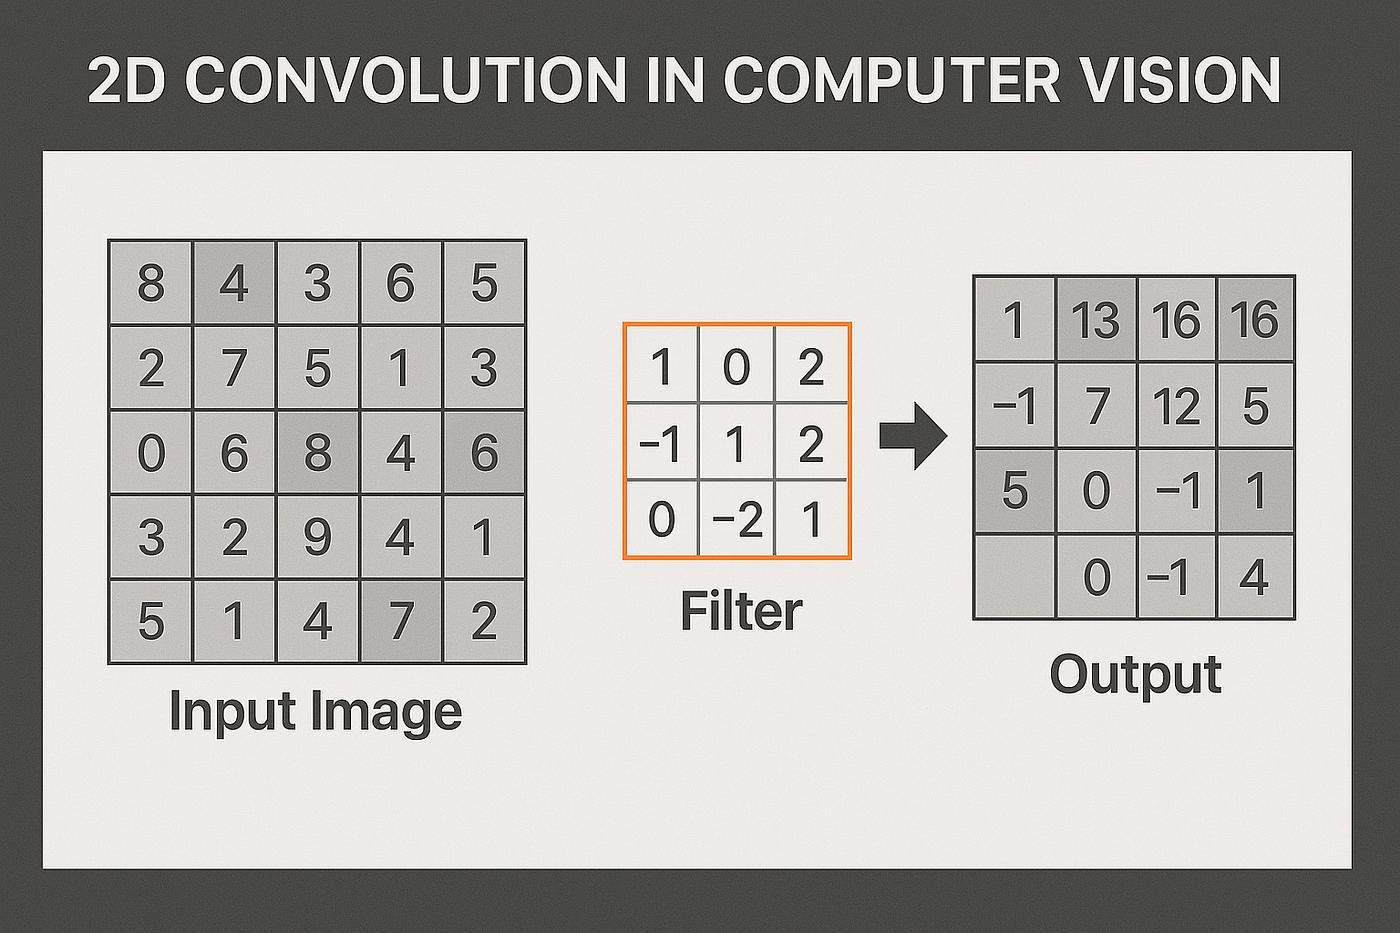
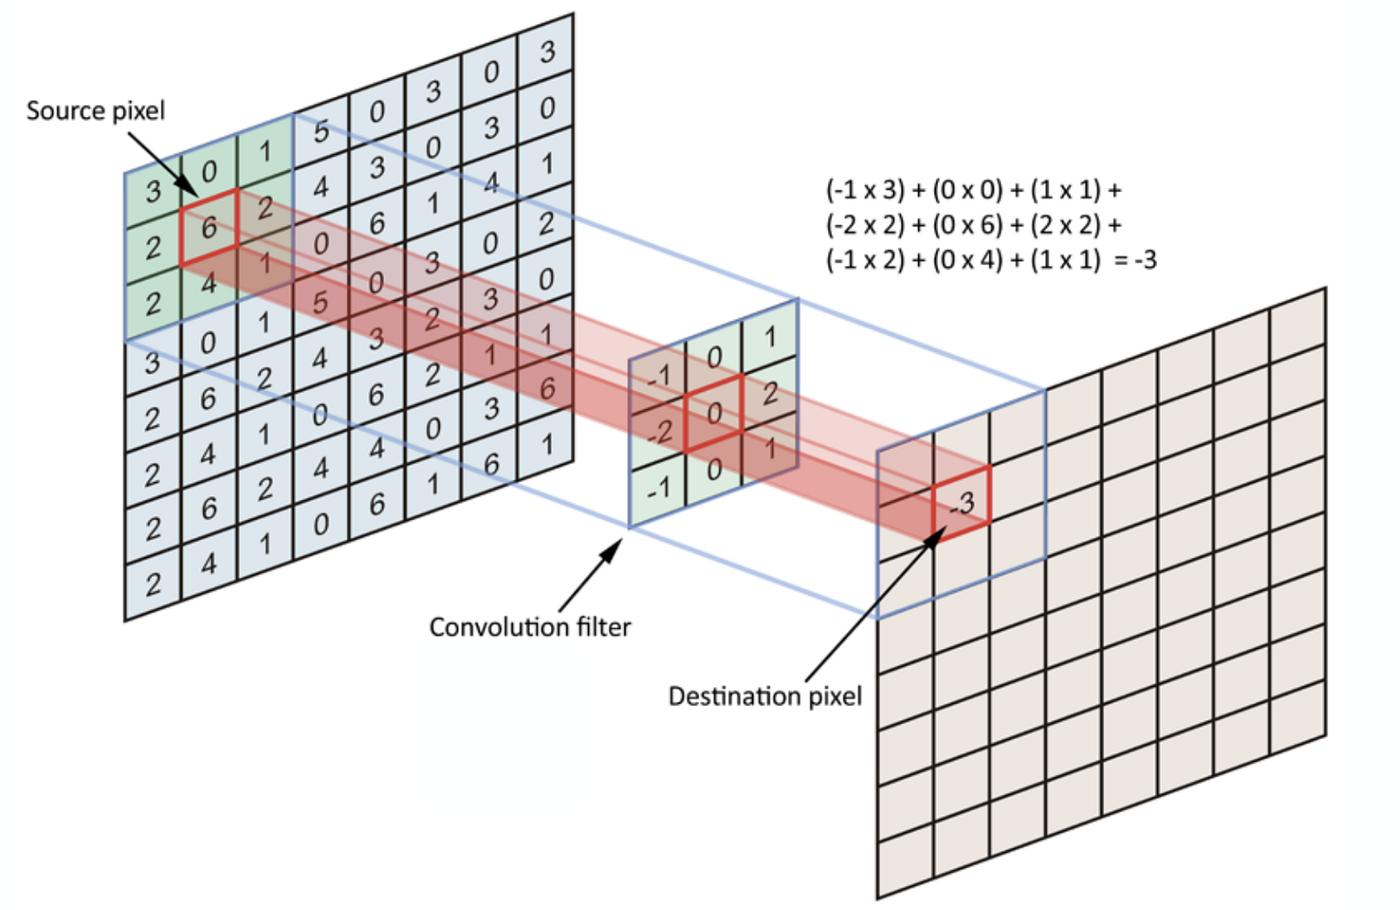

#### **Basic Idea**

Suppose we have a small image:

$$
I =
\begin{bmatrix}
1 & 2 & 3\\
4 & 5 & 6\\
7 & 8 & 9
\end{bmatrix}
$$

And a **3×3 filter/kernel**:

$$
K =
\begin{bmatrix}
1 & 0 & -1\\
1 & 0 & -1\\
1 & 0 & -1
\end{bmatrix}
$$

The convolution operation multiplies corresponding elements and then adds them.

$$
Output =
(1\times1)+(2\times0)+(3\times-1)
$$

$$
+(4\times1)+(5\times0)+(6\times-1)
$$

$$
+(7\times1)+(8\times0)+(9\times-1)
$$

Therefore:

$$
=1+0-3+4+0-6+7+0-9
$$

$$
=\boxed{-6}
$$

So, the kernel converts a small region of the image into **one output value**.

---

#### **Convolution Step-by-Step**

For a larger image, the kernel **slides across the image**. For example:

```text
Image                  Kernel

1  2  3  4             1  0
5  6  7  8             0  1
9 10 11 12
13 14 15 16
```

With a **2×2 kernel** we first look at:

```text
1  2
5  6
```

Perform element-wise multiplication:

```text
1×1 + 2×0
5×0 + 6×1
```

Result `1 + 6 = 7`. Then the kernel moves to the right:

```text
   2  3
   6  7
```

and calculates another value. It continues doing this across the entire image.

---

#### **Feature Map**

The output produced by convolution is called a **feature map** (or activation map). A feature map represents **where a particular feature exists in the image**. For example, one filter might detect:

* Vertical edges
* Horizontal edges
* Corners
* Textures
* Curves

Deeper CNN layers can learn more complex features such as:

```text
Edges
  ↓
Corners / textures
  ↓
Parts of objects
  ↓
Complete objects
```

---

#### **Kernel / Filter**

A **kernel** is a small matrix containing learnable weights. Example: $3\times3$

```text
[ w1  w2  w3 ]
[ w4  w5  w6 ]
[ w7  w8  w9 ]
```

During CNN training, these weights are **automatically learned** using backpropagation and gradient descent. You don't manually tell the CNN:

> "This filter should detect edges."

Instead, the network learns useful filters from the training data.

---

#### **Stride**

**Stride** determines how many pixels the kernel moves at each step.

* **Stride = 1:** `→ → → →` The kernel moves one pixel at a time.
* **Stride = 2:** `→   →   →` The kernel jumps two pixels at a time.

Larger stride generally produces a **smaller feature map**.

---

#### **Padding**

Padding adds extra pixels around the image, usually zeros.

Without padding:

```text
Input:       5 × 5
Kernel:      3 × 3
Output:      3 × 3
```

With padding = 1:

```text
Input:       5 × 5
Padding:     1
Kernel:      3 × 3
Output:      5 × 5
```

Padding is useful because it:

* Preserves spatial dimensions
* Allows border pixels to be processed more often
* Prevents rapid shrinking of feature maps

---

#### **Output Size Formula**

For a 2D convolution:

$$
Output =
\left\lfloor
\frac{N+2P-K}{S}
\right\rfloor+1
$$

Where:

* $N$ = input size
* $P$ = padding
* $K$ = kernel size
* $S$ = stride

#### **Example**

* Input: $32\times32$
* Kernel: $3\times3$
* Padding: $1$
* Stride:$1$
* Then:

$$
Output =
\frac{32+2(1)-3}{1}+1
$$

$$
=32
$$

So:

$$
\boxed{32\times32}
$$

---

#### **Convolution in PyTorch**

PyTorch provides convolution through `nn.Conv2d`.

In [1]:
import torch
import torch.nn as nn

conv = nn.Conv2d(
    in_channels=1,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)

This means the layer learns **16 different 3×3 filters**. For a grayscale image:

In [3]:
x = torch.randn(1, 1, 28, 28)
output = conv(x)
print(output.shape)

torch.Size([1, 16, 28, 28])


The dimensions mean:

```text
Batch size     = 1
Channels       = 16
Height         = 28
Width          = 28
```

#### **Complete Numerical Example + PyTorch**

Let's understand convolution in **two ways**:

1. 🧮 Manually with numbers
2. 💻 Using PyTorch

---

#### **What happens during convolution?**

A CNN takes a small **kernel/filter** and slides it over the input. For example, suppose our input is a `4 × 4` matrix:

$$
X=
\begin{bmatrix}
1&2&3&4\\
5&6&7&8\\
9&10&11&12\\
13&14&15&16
\end{bmatrix}
$$

Our kernel is:

$$
K=
\begin{bmatrix}
1&0\\
0&1
\end{bmatrix}
$$

We'll use:

* Kernel size = `2 × 2`
* Stride = `1`
* Padding = `0`

---

#### **Continue the process**

The kernel continues sliding across the image. The complete calculation is:
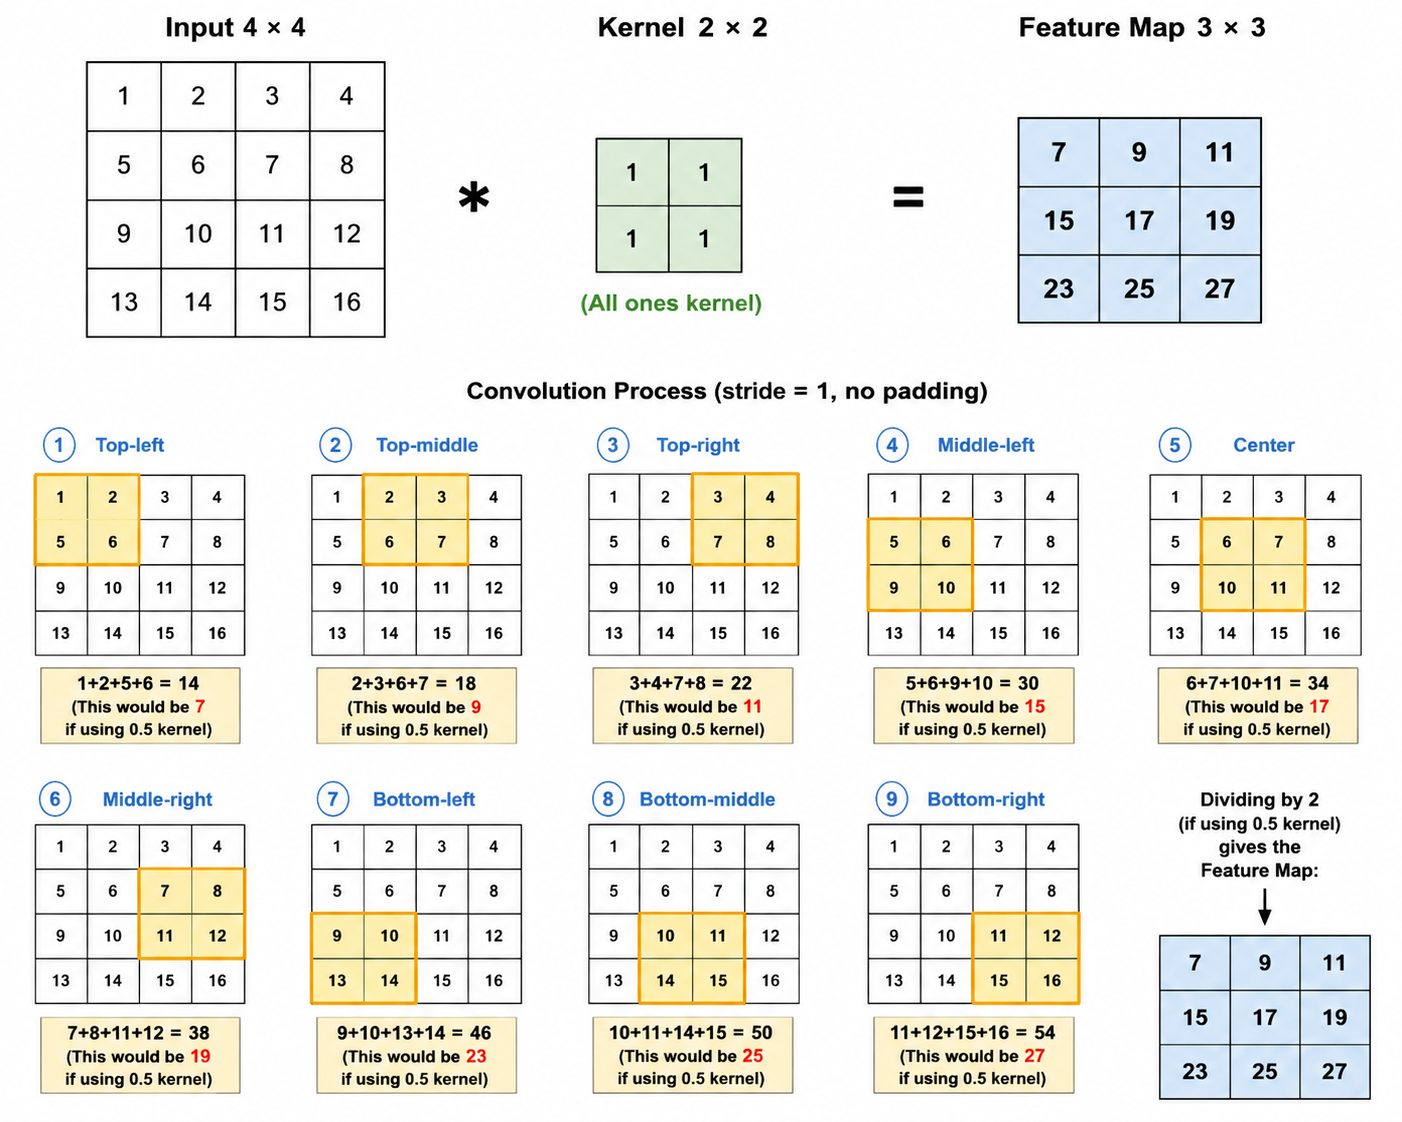

---

#### **Why is the output `3 × 3`?**

We started with $4\times4$ and used $2\times2$ kernel with:

* Padding = 0
* Stride = 1

The output-size formula is:

$$
O=\frac{N+2P-K}{S}+1
$$

Therefore:
$$
O=\frac{4+2(0)-2}{1}+1
$$
$$
=3
$$

So $\boxed{3\times3}$

---

#### **Important: CNN convolution is slightly different**

In deep learning, what is commonly called **convolution** is technically **cross-correlation**. The kernel is normally **not flipped** before multiplication. So PyTorch:

```python
nn.Conv2d()
```

performs cross-correlation. For learning CNNs, you can simply remember:

> **A kernel slides over the input, performs element-wise multiplication, sums the results and produces a feature map.**

---

#### **Implement in PyTorch**

In [4]:
import torch
import torch.nn as nn

# Input 
X = torch.tensor([
    [1.,  2.,  3.,  4.],
    [5.,  6.,  7.,  8.],
    [9., 10., 11., 12.],
    [13., 14., 15., 16.]
])

# Kernel
K = torch.tensor([
    [1., 0.],
    [0., 1.]
])

However, `Conv2d` expects a **4-dimensional tensor**:

```text
(batch, channels, height, width)
```

So we reshape the input:

In [5]:
X = X.reshape(1, 1, 4, 4)
print(X.shape)

torch.Size([1, 1, 4, 4])


---

#### **Create the convolution layer**

In [7]:
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=2,
    stride=1,
    padding=0,
    bias=False
)

We use `bias=False` because we want to reproduce our manual calculation exactly. Now replace the randomly initialized kernel with our kernel:

In [8]:
with torch.no_grad():
    conv.weight.copy_(K.reshape(1, 1, 2, 2))

---

#### **Perform convolution**

In [10]:
output = conv(X)
print(output)
print(output.shape)

tensor([[[[ 7.,  9., 11.],
          [15., 17., 19.],
          [23., 25., 27.]]]], grad_fn=<ConvolutionBackward0>)
torch.Size([1, 1, 3, 3])
